In [1]:
import OptimalBattery.simulate as sim
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import binary_dilation, binary_erosion, shift
import numpy as np
import OptimalBattery.construct as ct
import OptimalBattery.util as ut
import OptimalBattery.estimate as et
import seaborn as sns
from scipy.stats import gamma


In [2]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')

# start with some U_true, in this simulation its 5 parcels
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]

   
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.from_numpy(U_true_5).to(device=device, dtype=pt.float64)

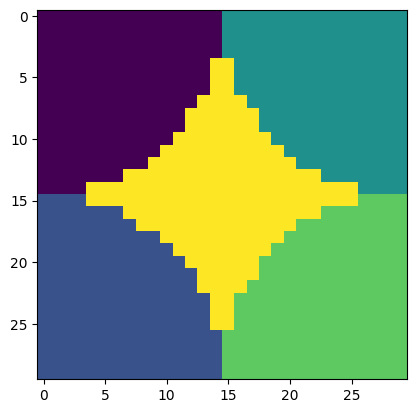

In [3]:
# convert with
labels = pt.argmax(U_true_5, axis=0)  # shape = (P,)
label_map = labels.reshape(30, 30) 
plt.imshow(label_map.cpu().numpy())

In [4]:
def make_individuals_vary_last(U_true, grid, n_individuals=8,
                               shift_range=3, size_jitter=2,
                               seed=None, device=None):
    """
    Make individual parcellations where only the last parcel moves or changes size.
    
    shift_range : how many pixels to shift parcel 5 (random x/y)
    size_jitter : how much to grow/shrink parcel 5
    """
    if seed is not None:
        np.random.seed(seed)

    if isinstance(U_true, pt.Tensor):
        U_true = U_true.detach().cpu().numpy()

    K, P = U_true.shape
    width, height = grid.width, grid.height
    base_labels = np.argmax(U_true, axis=0).reshape(width, height)

    individuals = []
    for _ in range(n_individuals):
        new_labels = base_labels.copy()

        # extract parcel 5 mask (last parcel)
        k = K - 1
        mask = (base_labels == k).astype(float)

        # random small spatial shift
        dx = np.random.randint(-shift_range, shift_range + 1)
        dy = np.random.randint(-shift_range, shift_range + 1)
        mask_shifted = shift(mask, shift=(dx, dy), order=0, mode='nearest')

        # random growth or shrinkage
        if np.random.rand() < 0.5:
            mask_shifted = binary_dilation(mask_shifted, iterations=np.random.randint(1, size_jitter + 1))
        else:
            mask_shifted = binary_erosion(mask_shifted, iterations=np.random.randint(1, size_jitter + 1))

        # update the parcel in the label map
        new_labels[mask_shifted > 0] = k

        # rebuild binary membership matrix
        U_ind = np.zeros((K, P))
        for kk in range(K):
            U_ind[kk, new_labels.flatten() == kk] = 1

        if device is not None:
            U_ind = pt.from_numpy(U_ind).to(device=device, dtype=pt.float64)

        individuals.append(U_ind)

    return individuals



In [5]:
U_individuals = make_individuals_vary_last(
    U_true_5, grid,
    n_individuals=50,
    shift_range=8,   # move up to ±3 pixels
    size_jitter=3,   # grow/shrink parcel 5
    seed=42,
    device=device
)



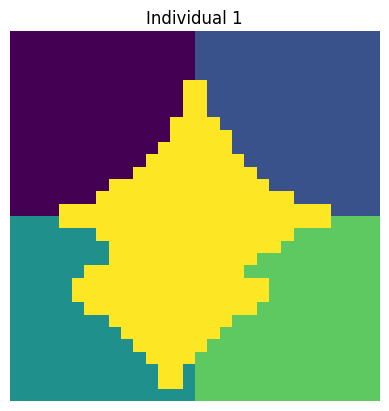

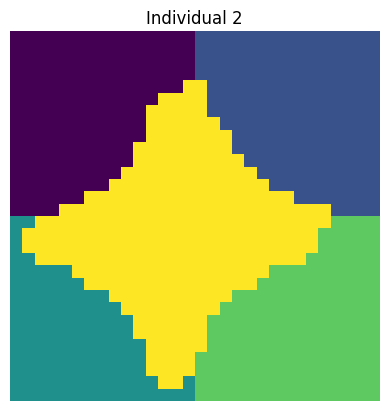

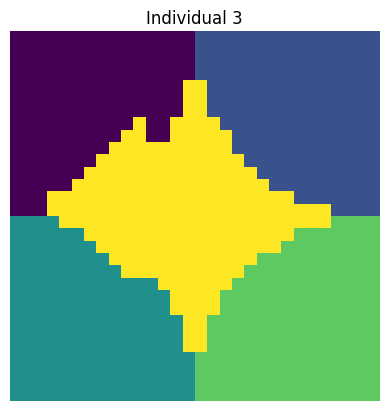

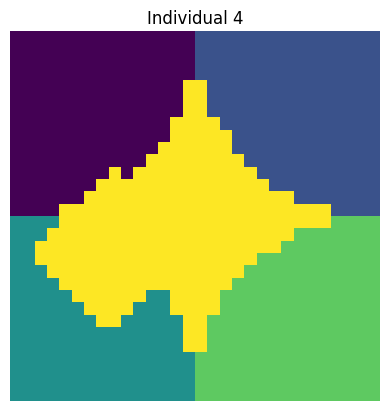

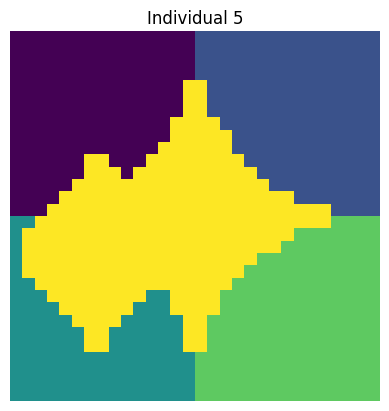

In [6]:
for i, U in enumerate(U_individuals[:5]):
    label_map = np.argmax(U.cpu().numpy(), axis=0).reshape(30, 30)
    plt.imshow(label_map.T)
    plt.title(f'Individual {i+1}')
    plt.axis('off')
    plt.show()


In [7]:
U_collapsed_list = []
target_indices = [4]

for U_ind in U_individuals:
    U_collapsed = sim.collapse_U(U_ind, target_parcels_indices=target_indices)
    U_collapsed_list.append(U_collapsed)



In [8]:
snr_list = [1.3115151774608331, 1.4149032130622416, 1.2109707527775373, 1.6068611536892698, 1.1657993647698808, 1.395539359540918, 1.5078137659693904, 1.2722970483343168, 1.2130245876149006, 1.3168092460527587, 1.542197184797918, 1.193532802872774, 1.318515240873169, 1.3492878085827293, 1.1691889901956514, 1.4832808835812712, 1.3095999179473812, 1.2875932193289648, 1.263232655076339, 1.3221711097899023, 1.2552691555387832, 1.1969497723202638, 1.167932690905133, 1.1488975119094191]
shape, loc, scale = gamma.fit(snr_list, floc=0)  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


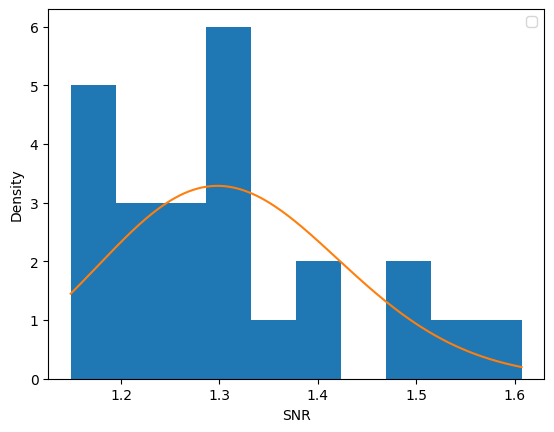

In [9]:
# Plot histogram and fitted PDF
x = np.linspace(min(snr_list), max(snr_list), 200)
pdf = gamma.pdf(x, shape, loc, scale)

plt.hist(snr_list, bins=10)
plt.plot(x, pdf)
plt.xlabel("SNR")
plt.ylabel("Density")
plt.legend()
plt.show()

In [10]:
results_df = pd.DataFrame()
base_noise = 0.4
max_n_task = 1
types = ['single_threshold','multi']

parcellation_single = []
parcellation_multi = []
for type in types:
    rng= np.random.default_rng(42)
    V_lib = rng.normal(0,1,(max_n_task, 5))
    V_lib = V_lib - V_lib.mean(axis=0,keepdims=True)
    G_lib = V_lib @ V_lib.T
    V_lib = pt.tensor(V_lib, dtype=pt.float64, device=device)

    # get the single contrast
    if type == 'single_50' or type == 'single_threshold':
        max_idx, min_idx = sim.find_max_contrast_against_all(V_lib, 4)
        combination = [max_idx, min_idx]
    else:
        combination = [0,1,2,3,4]

    # get the V localizer
    V_battery = V_lib[combination,:]
    n_task = V_battery.shape[0]

    # Battery-level noise (same for all subs)
    weighted_noise_std = sim.get_weighted_noise_std(n_task=n_task, max_n_task=max_n_task, noise=base_noise)
    battery_noise = rng.normal(0, weighted_noise_std, (V_battery.shape[0], U_individuals[0].shape[1]))
    battery_noise = pt.tensor(battery_noise, dtype=pt.float64, device=device)

    for individual in range(len(U_individuals)):
        # get the data for the parcellation estimation and add noise
        Y_battery = V_battery @ U_individuals[individual]

        # subject-specific SNR variation
        rng_sub = np.random.default_rng(seed=individual)
        # snr_factor = rng_sub.lognormal(mean=0, sigma=0.4)  # >1 cleaner, <1 noisier
        snr_factor = rng_sub.gamma(shape, scale=scale)
        Y_battery = Y_battery * snr_factor

        # add battery-level noise
        Y_battery = Y_battery + battery_noise

        if type == 'multi':
            Y_battery = ut.center_matrix(Y_battery,axis=0)
            Y_battery = ut.normalize_matrix(Y_battery,axis=0)

            V_battery = ut.center_matrix(V_battery,axis=0)
            V_battery = ut.normalize_matrix(V_battery,axis=0)

            U_hat = et.estimate_Us(Y_battery, V_battery, method='correlation', hard=True)
            U_hat= sim.collapse_U(U_hat, target_parcels_indices=[4])[0]
            parcellation_multi.append(U_hat.cpu().numpy())

        elif type == 'single_threshold':
            U_hat = sim.make_thresholded_contrast(Y_battery[0,:], Y_battery[1,:],threshold= 2,mode='absolute')
            parcellation_single.append(U_hat.cpu().numpy())

        elif type == 'single_50':
            U_hat = sim.make_thresholded_contrast(Y_battery[0,:], Y_battery[1,:], 0.5)

        predicted_size = U_hat[0, :].sum().item()

        # Evaluate the contrast
        accuracy = sim.get_dice_single(U_collapsed_list[individual], U_hat)
        D_ev = pd.DataFrame()
        D_ev['type'] = [type]
        D_ev['n_tasks'] = [n_task]
        D_ev['snr_factor'] = [snr_factor]
        D_ev['individual'] = [individual]
        D_ev['accuracy'] = accuracy
        D_ev['predicted_size'] = predicted_size
        D_ev['true_size'] = U_collapsed_list[individual][0,:].sum().item()
        results_df = pd.concat([results_df,D_ev],axis=0)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


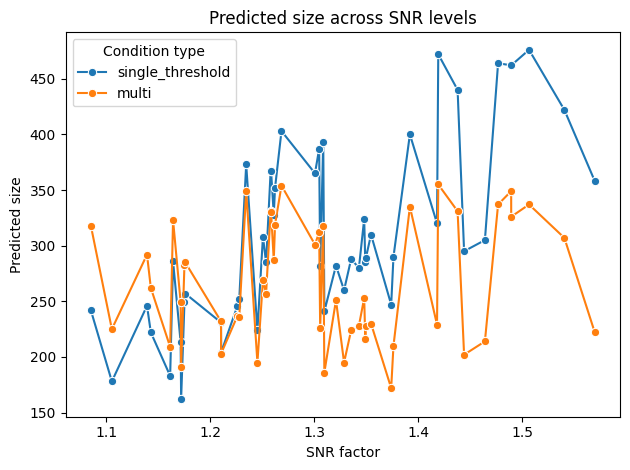

In [ ]:
sns.lineplot(
    data=results_df,
    x="snr_factor",
    y="predicted_size",
    hue="type",
    marker="o",
    err_style="bars",
)

plt.title("Predicted size across SNR levels")
plt.xlabel("SNR factor")
plt.ylabel("Predicted size")
plt.legend(title="Condition type")
plt.tight_layout()
plt.show()

In [ ]:
# corrrelations between SNR factor predicted size for single vs multi
corr_single = np.corrcoef(
    results_df[results_df['type'] == 'single_threshold']['predicted_size'], results_df[results_df['type'] == 'single_threshold']['snr_factor']
)[0, 1]
print("Correlation single threshold SNR vs predicted size:", corr_single)

# corrrelations between SNR factor predicted size for single vs multi
corr_multi = np.corrcoef(
    results_df[results_df['type'] == 'multi']['predicted_size'], results_df[results_df['type'] == 'multi']['snr_factor']
)[0, 1]
print("Correlation multi SNR vs predicted size:", corr_multi)

Correlation single threshold SNR vs predicted size: 0.6748859049858608
Correlation multi SNR vs predicted size: 0.21214034336602952


C:\Users\barafat\AppData\Local\Temp\ipykernel_14712\3733574487.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


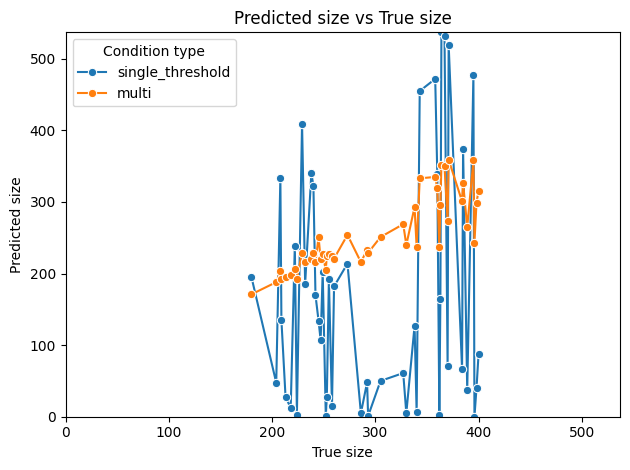

In [ ]:
sns.lineplot(
    data=results_df,
    x="true_size",
    y="predicted_size",
    hue="type",
    marker="o",
    err_style="bars",
    ci=None
)

# Enforce same range for both axes
min_val = results_df[['true_size', 'predicted_size']].min().min()
max_val = results_df[['true_size', 'predicted_size']].max().max()
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.title("Predicted size vs True size")
plt.xlabel("True size")
plt.ylabel("Predicted size")
plt.legend(title="Condition type")
plt.tight_layout()
plt.show()

In [ ]:
mse_single = np.mean((
    results_df[results_df['type'] == 'single_threshold']['predicted_size'] -
    results_df[results_df['type'] == 'single_threshold']['true_size']
) ** 2)

print("MSE single threshold:", mse_single)

mse_multi = np.mean((
    results_df[results_df['type'] == 'multi']['predicted_size'] -
    results_df[results_df['type'] == 'multi']['true_size']
) ** 2)
print("MSE multi:", mse_multi)

MSE single threshold: 46641.34
MSE multi: 3421.14


<Axes: xlabel='type', ylabel='accuracy'>

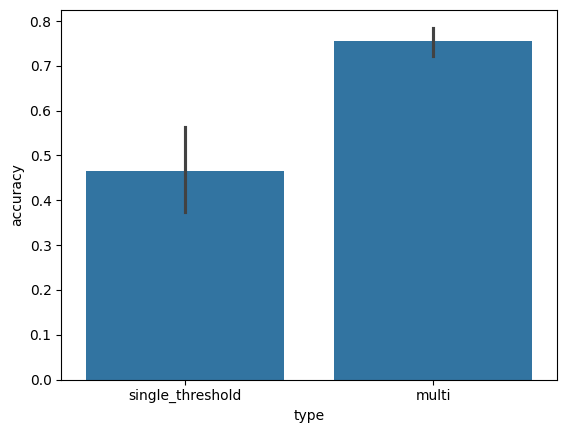

In [ ]:
sns.barplot(
    data=results_df,
    x="type",
    y="accuracy")

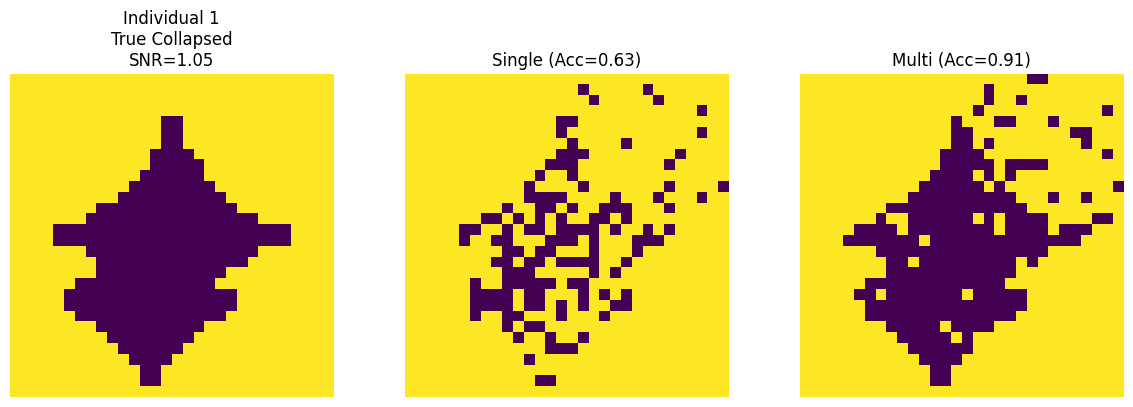

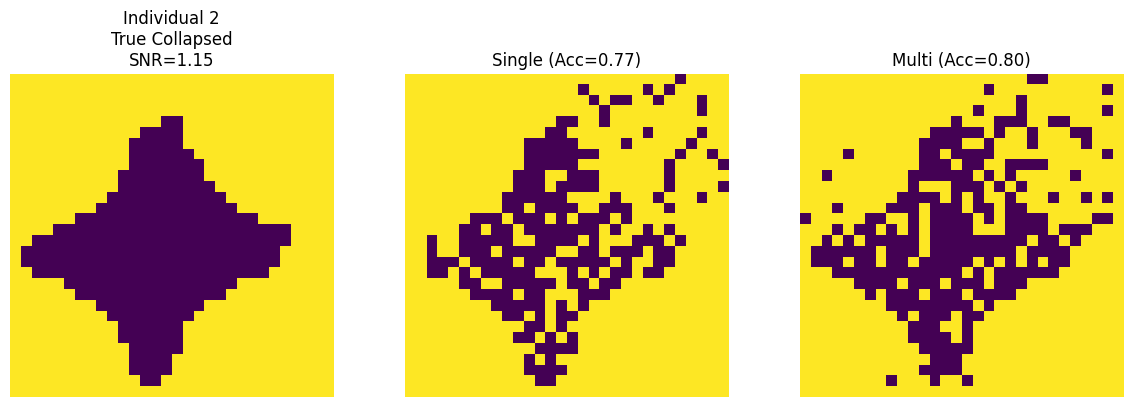

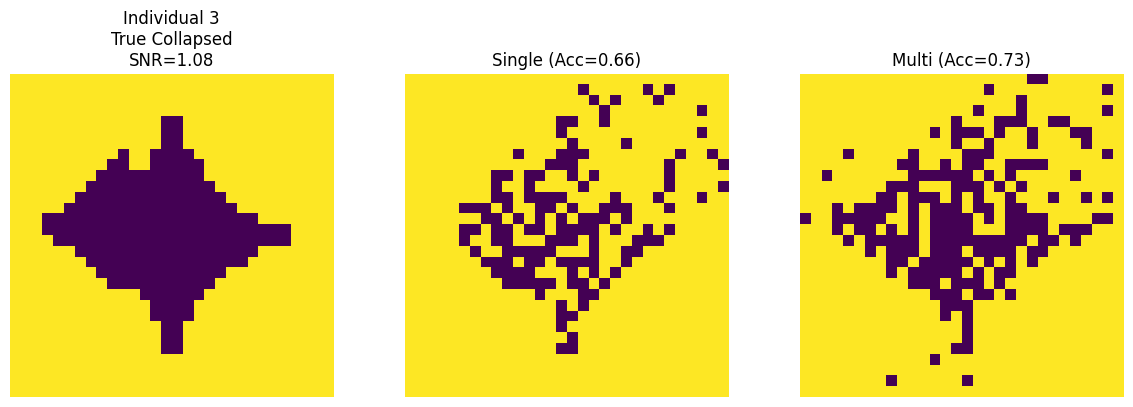

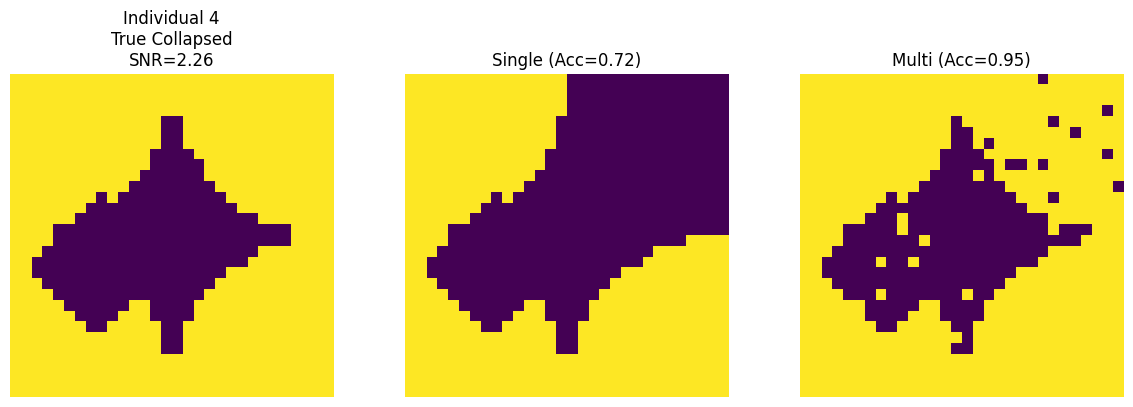

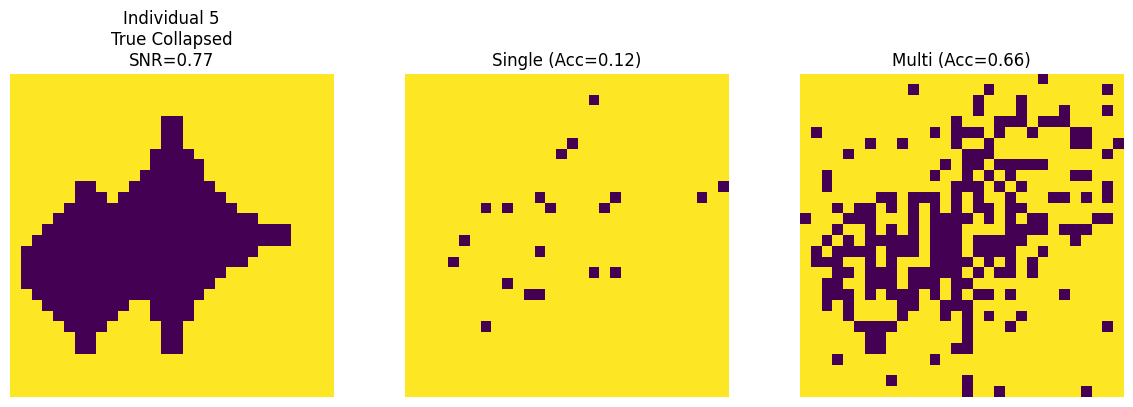

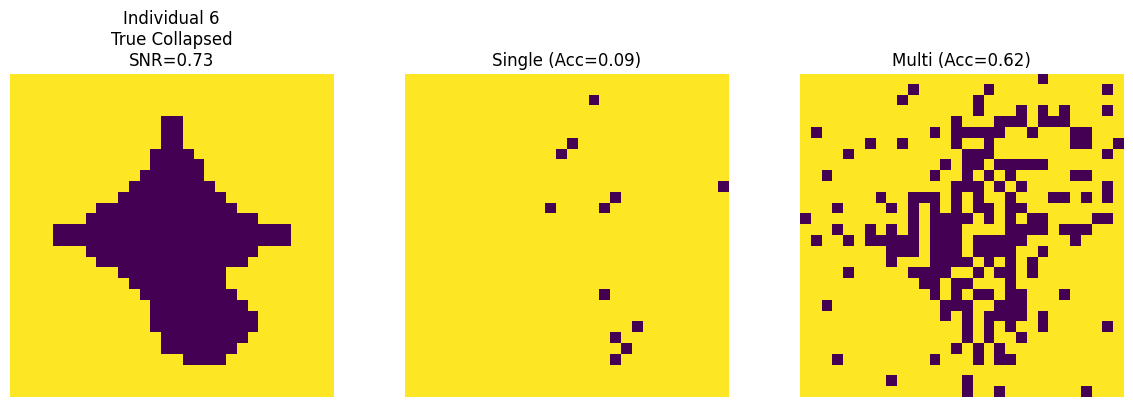

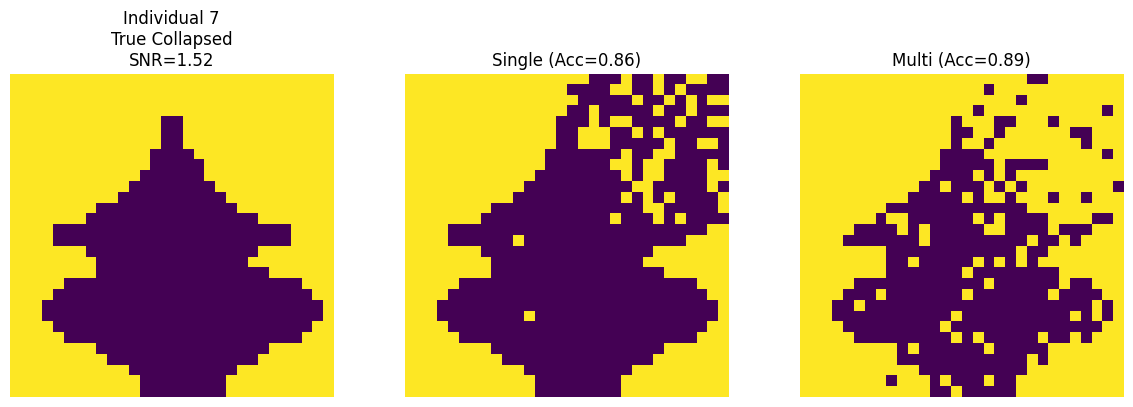

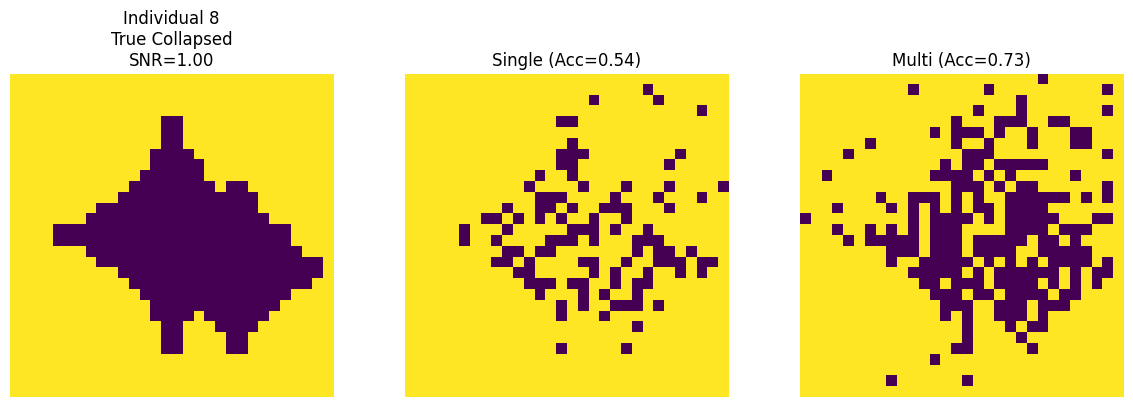

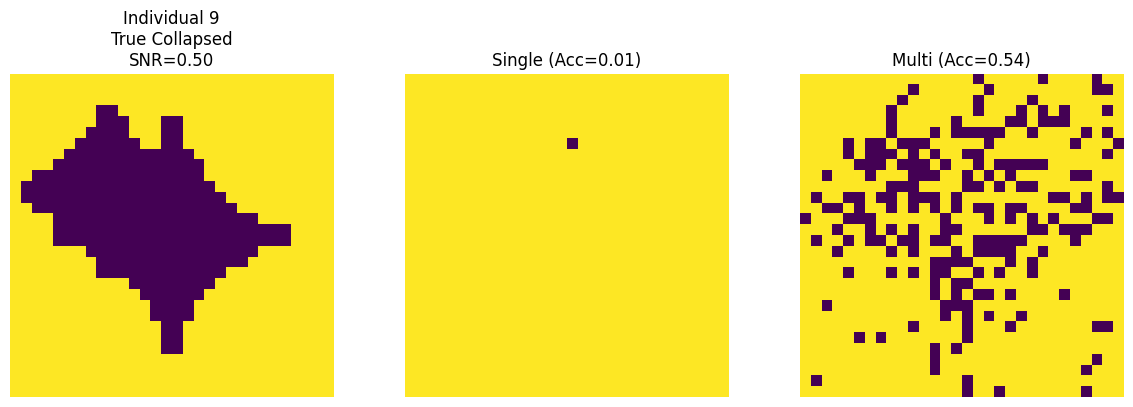

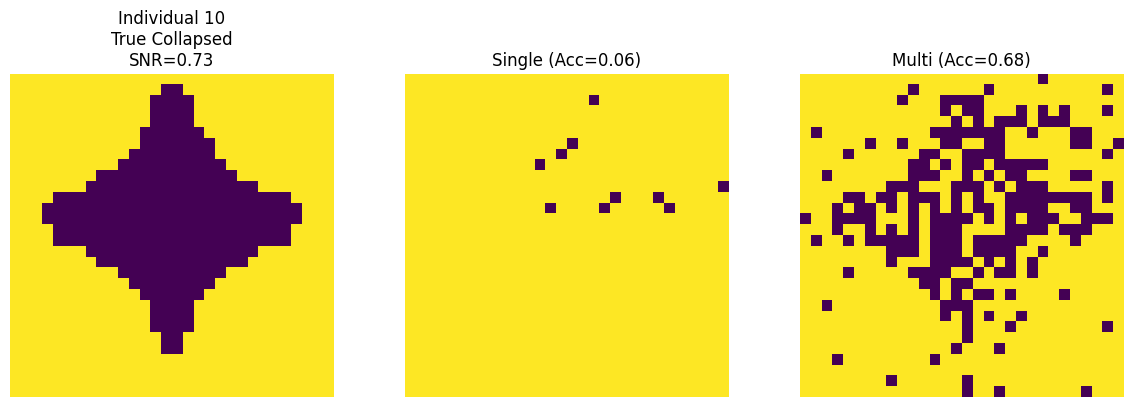

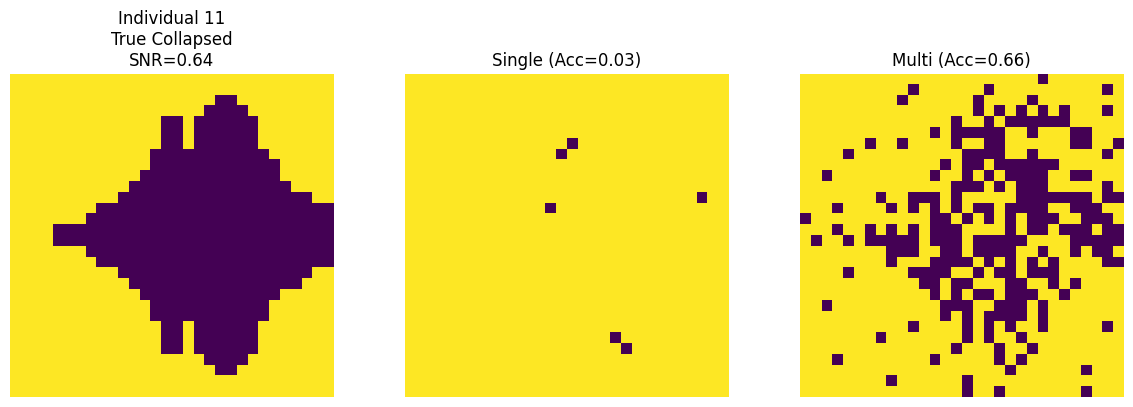

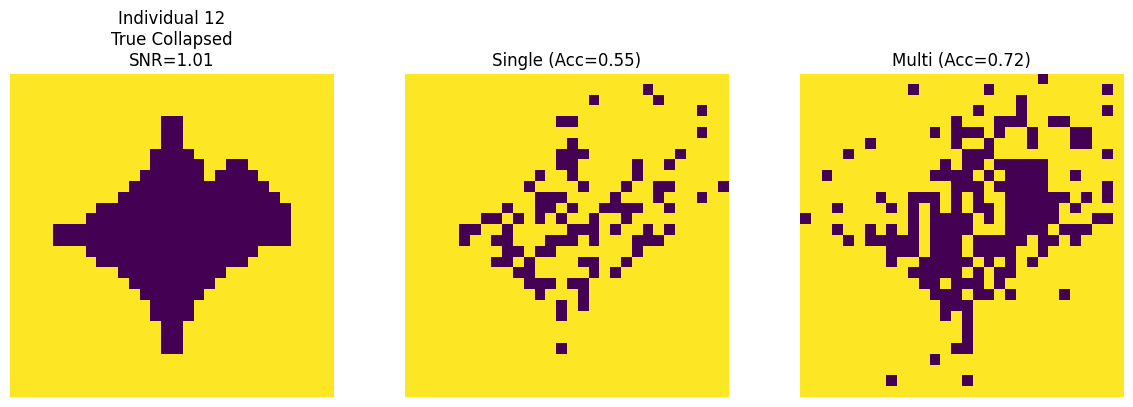

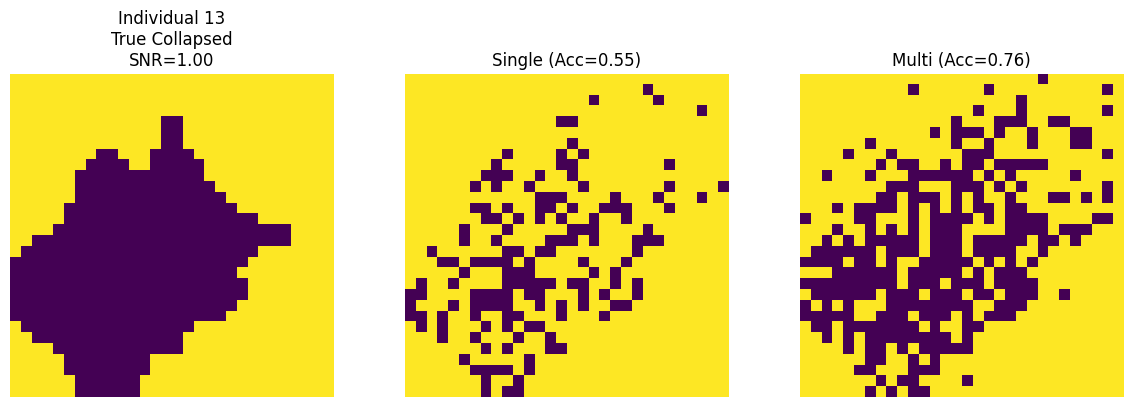

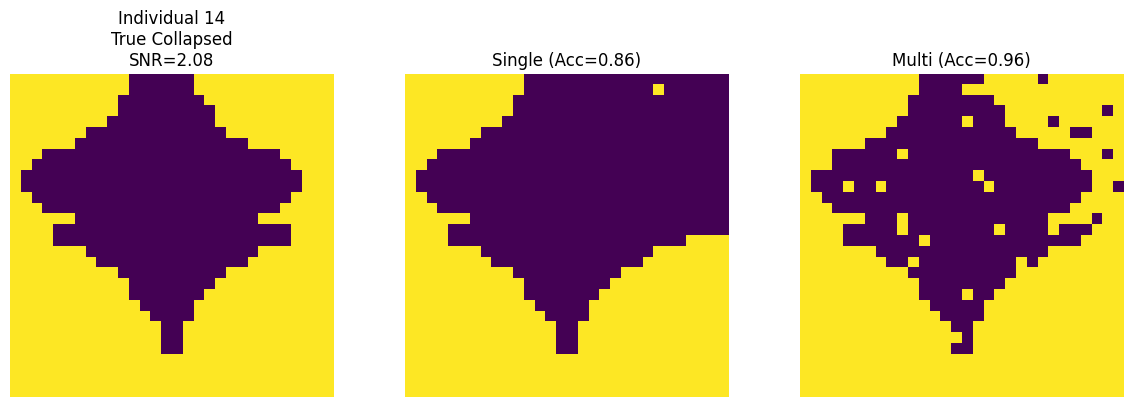

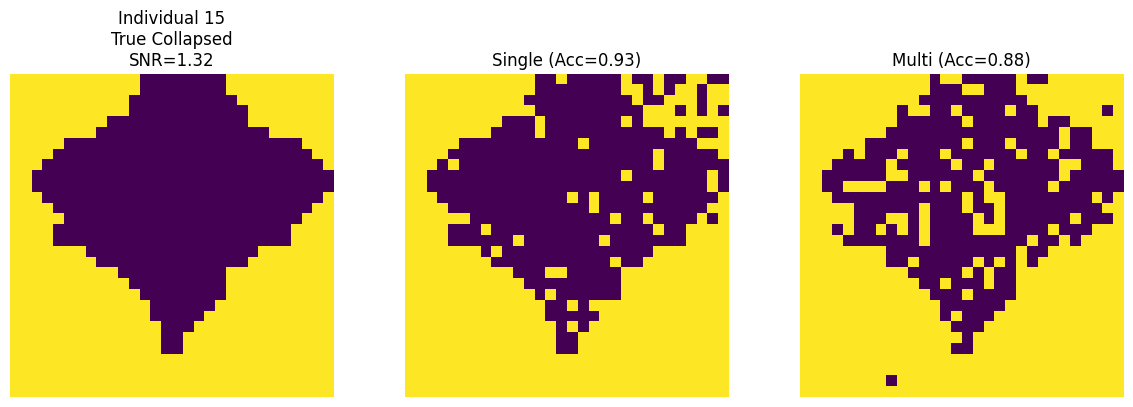

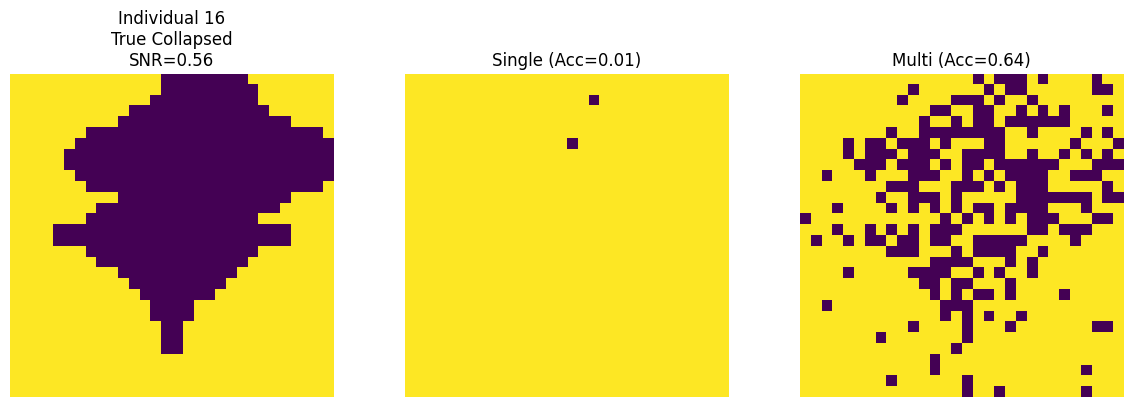

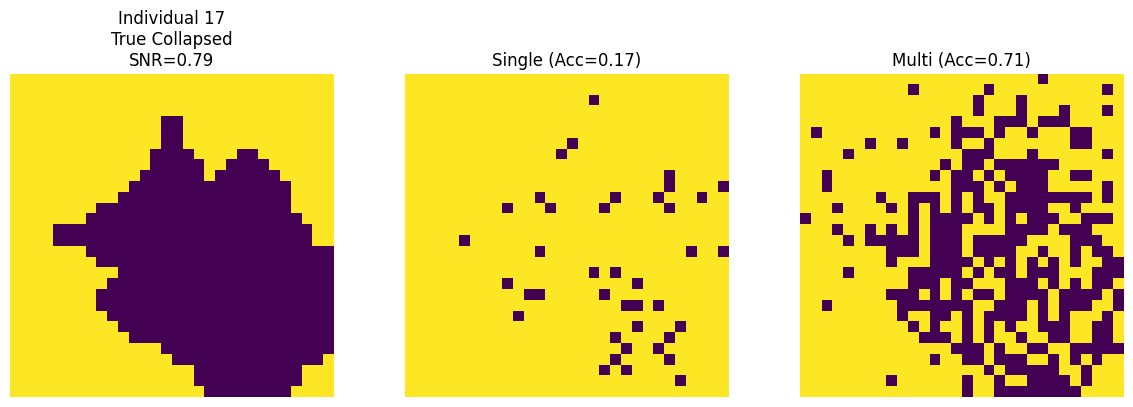

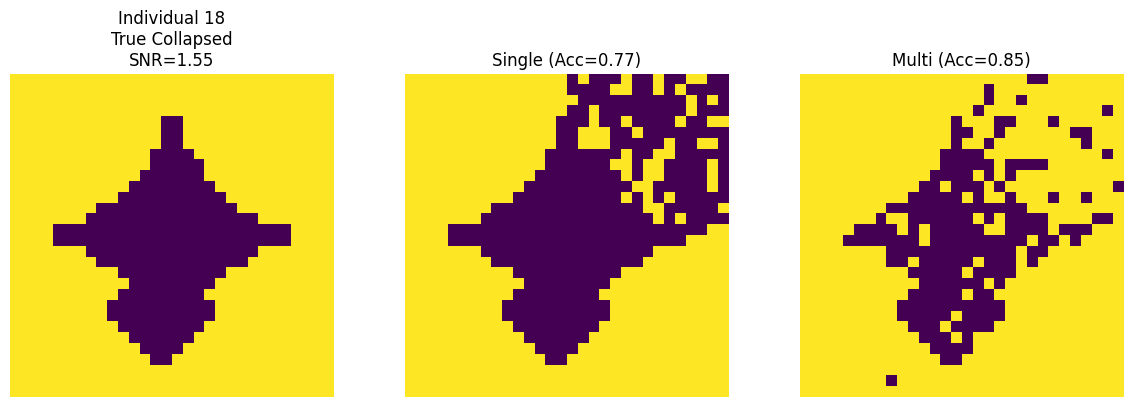

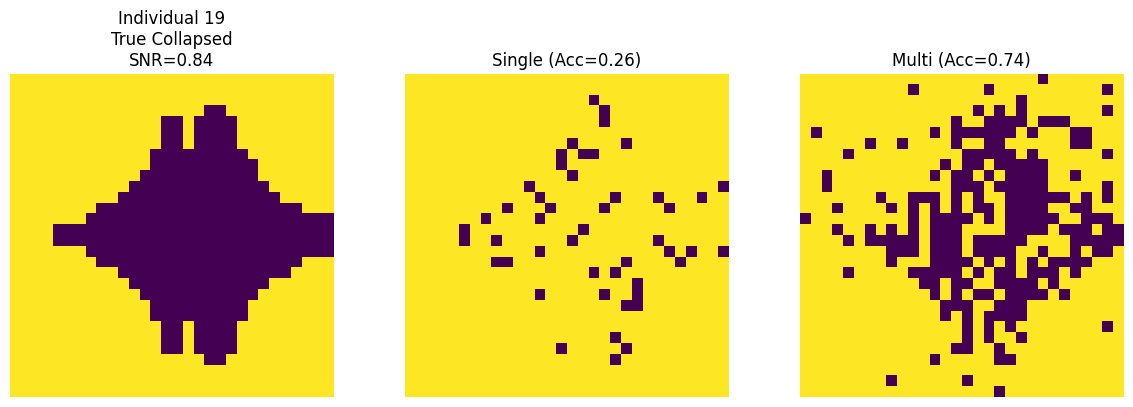

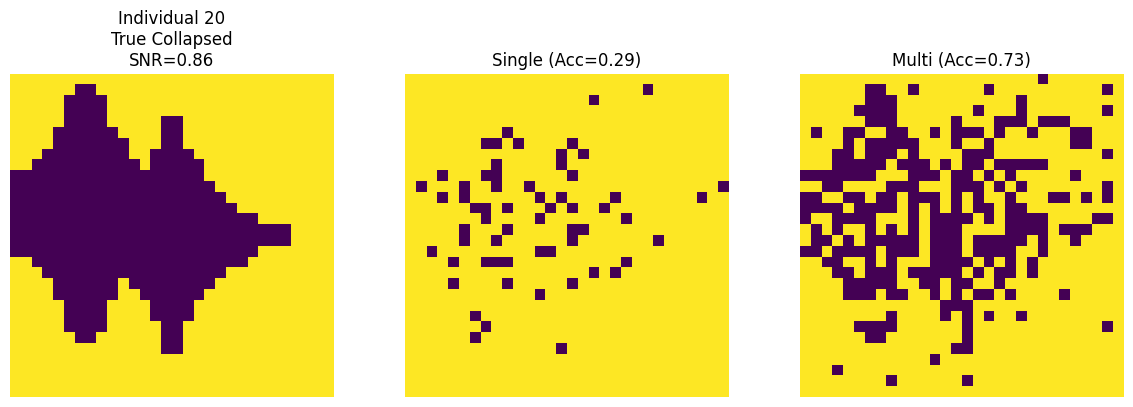

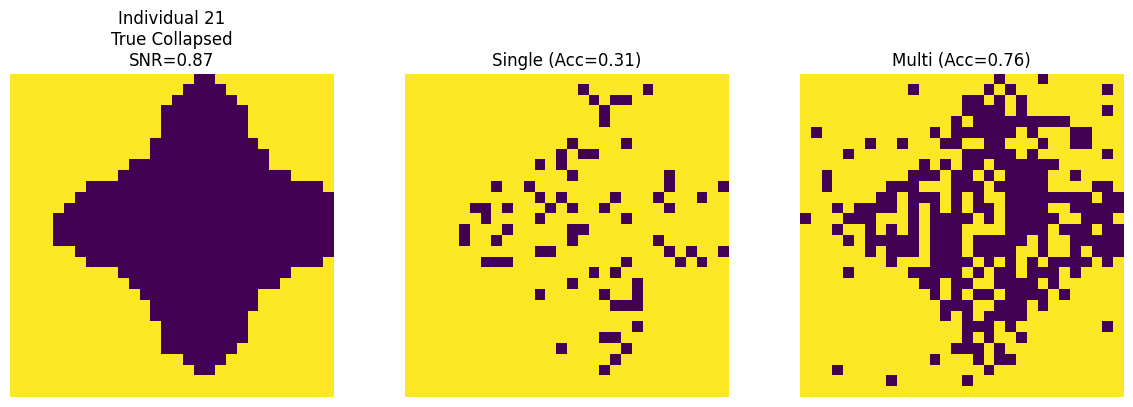

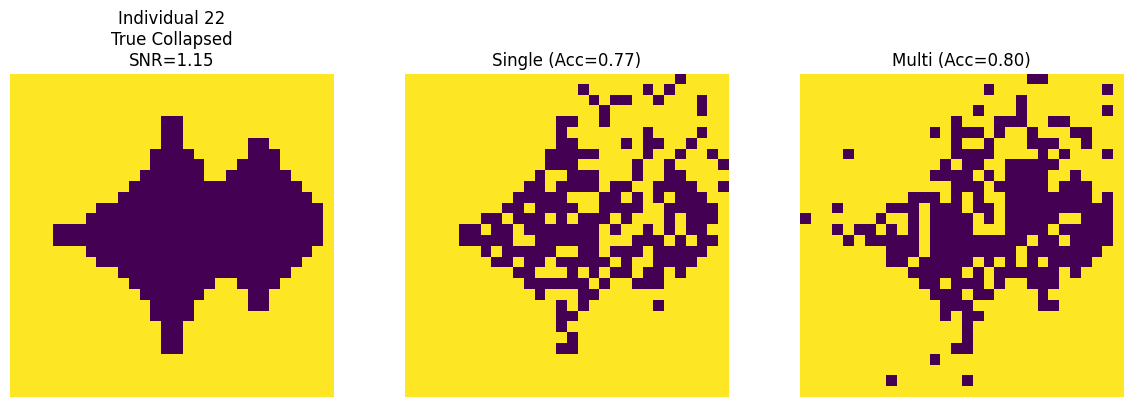

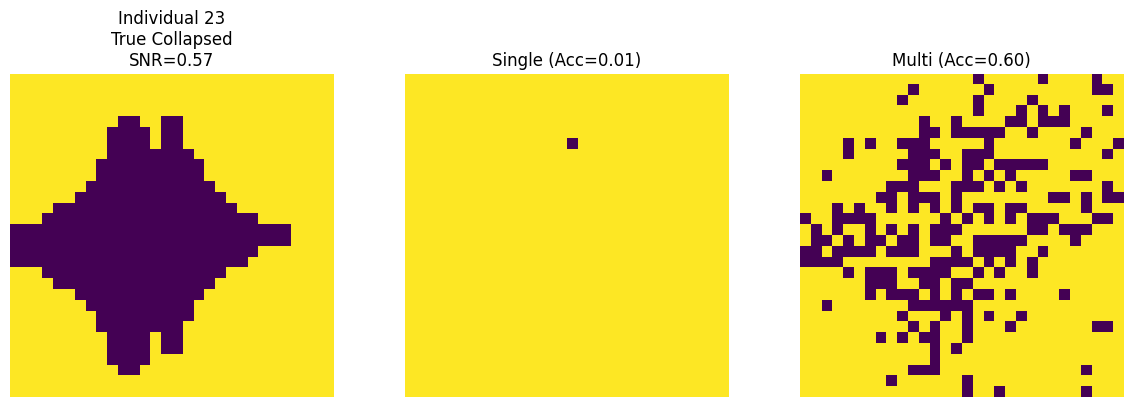

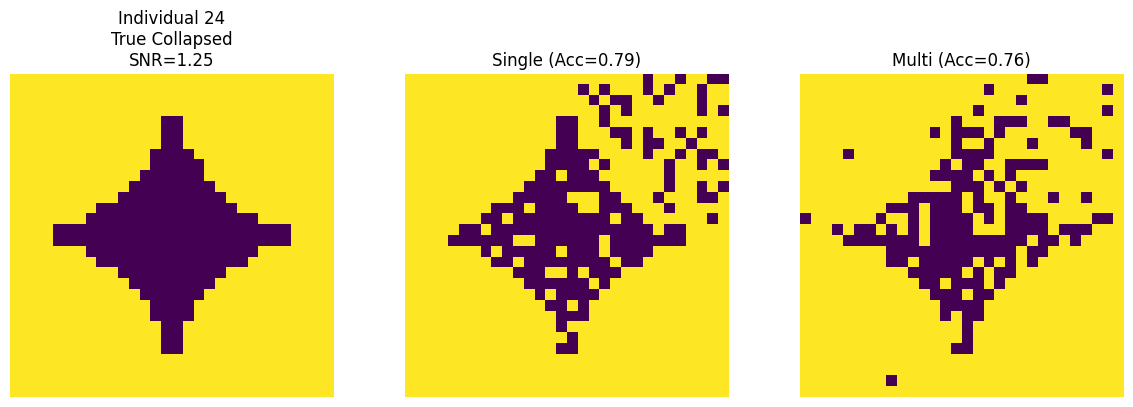

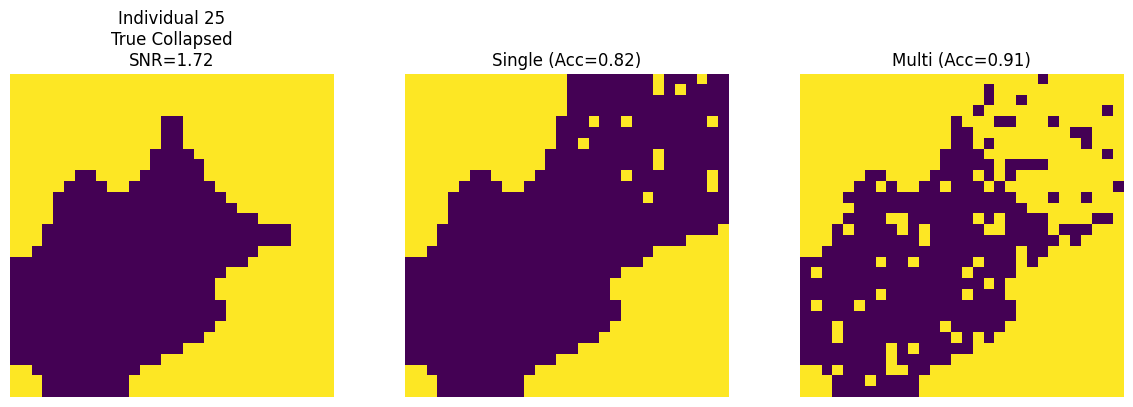

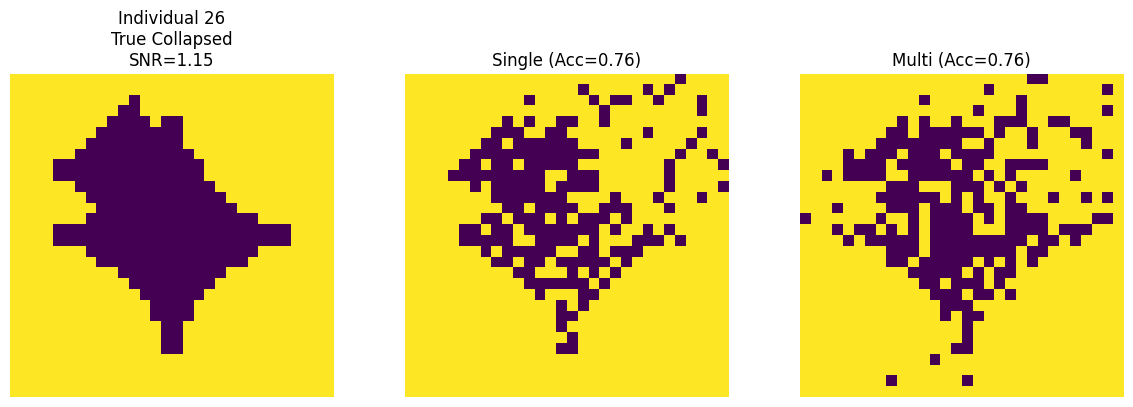

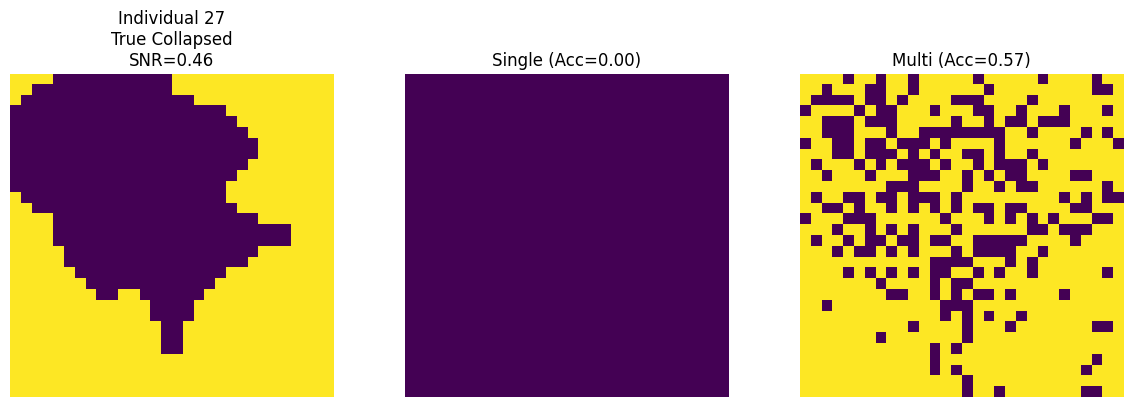

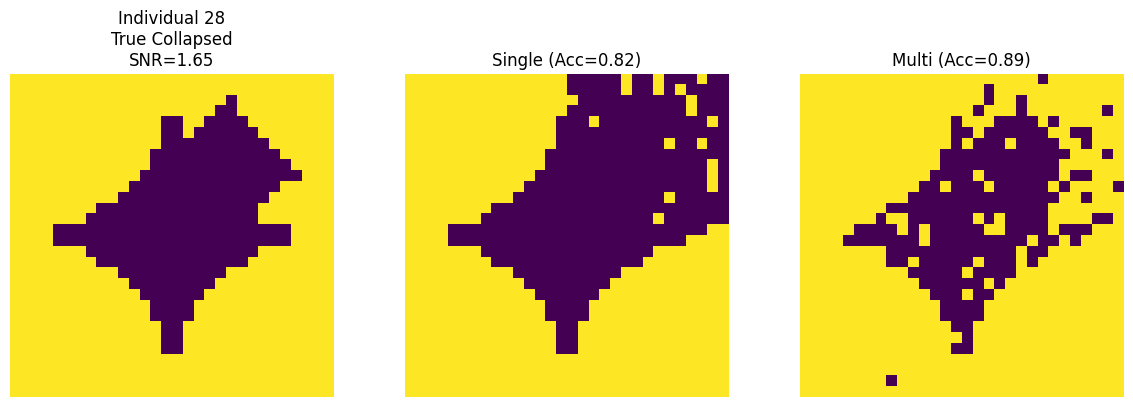

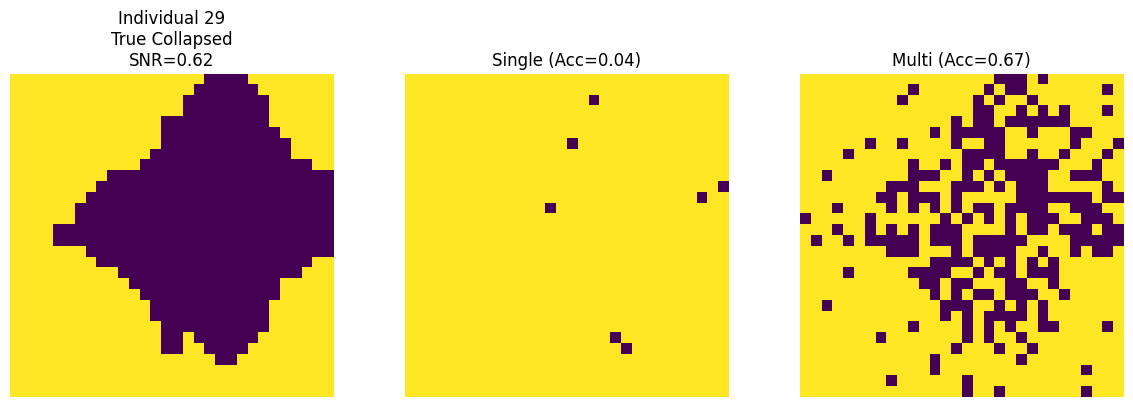

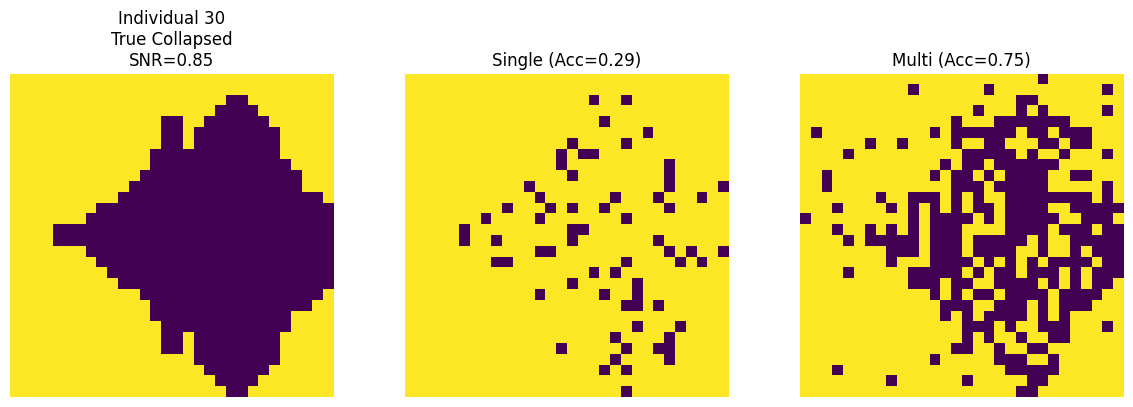

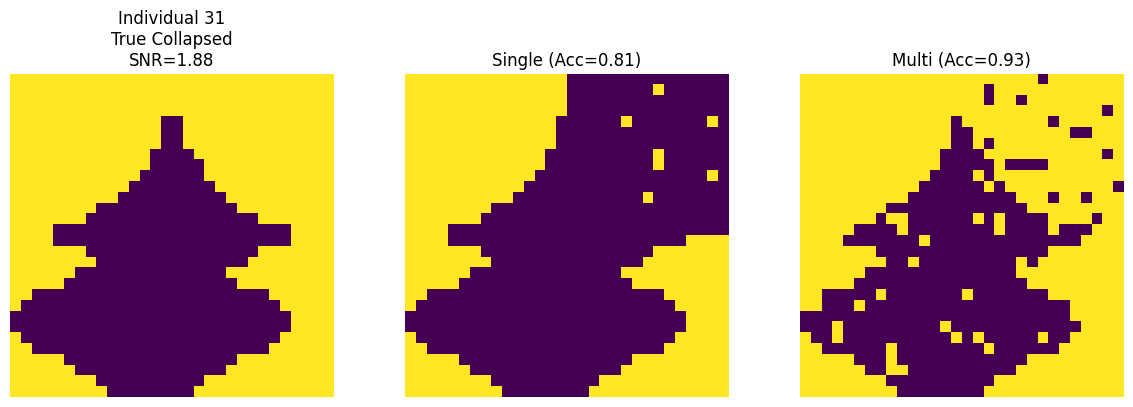

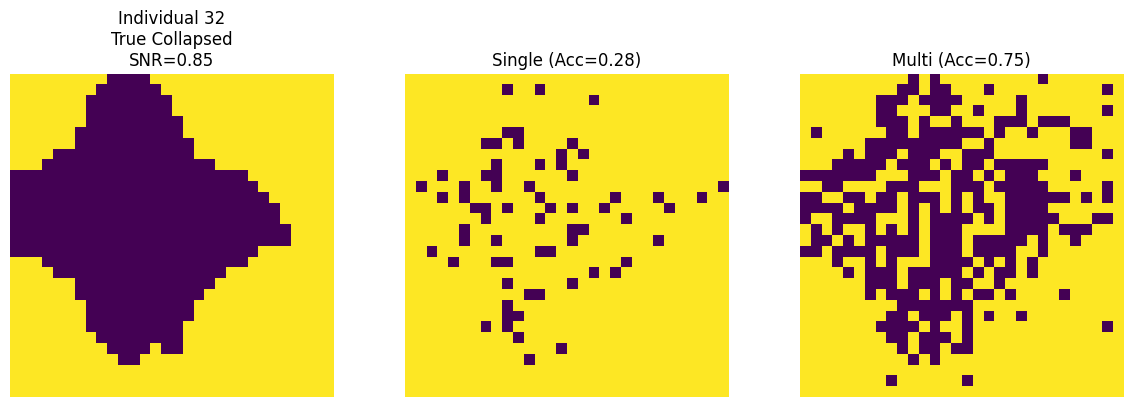

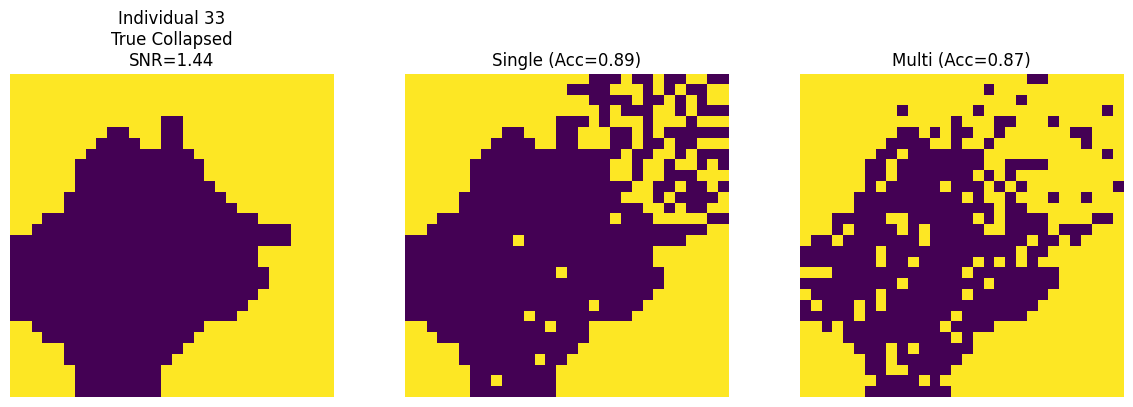

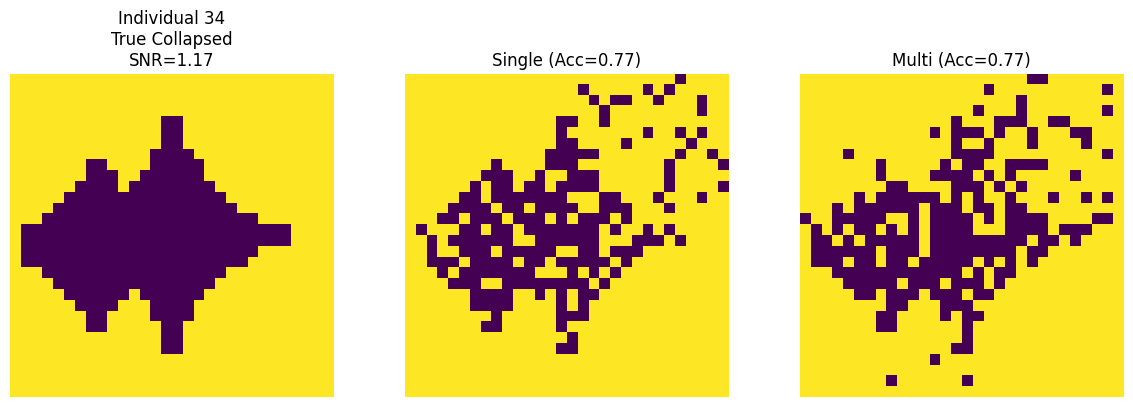

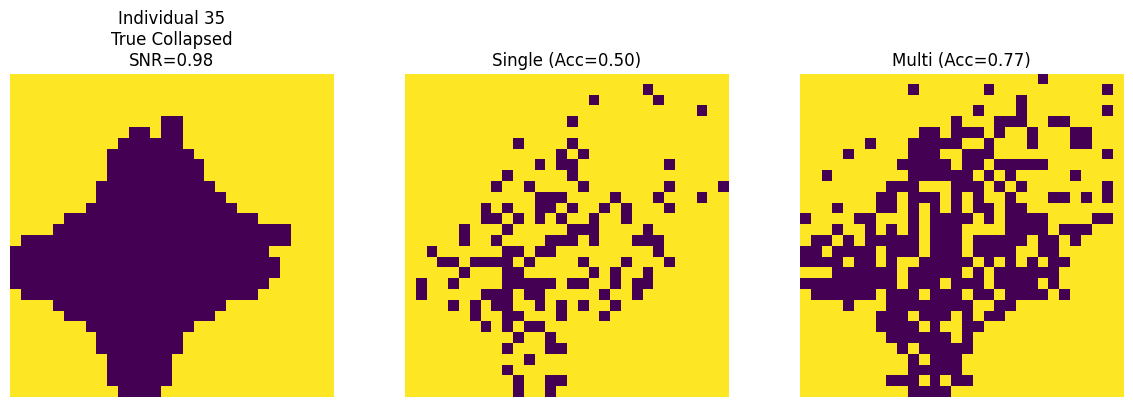

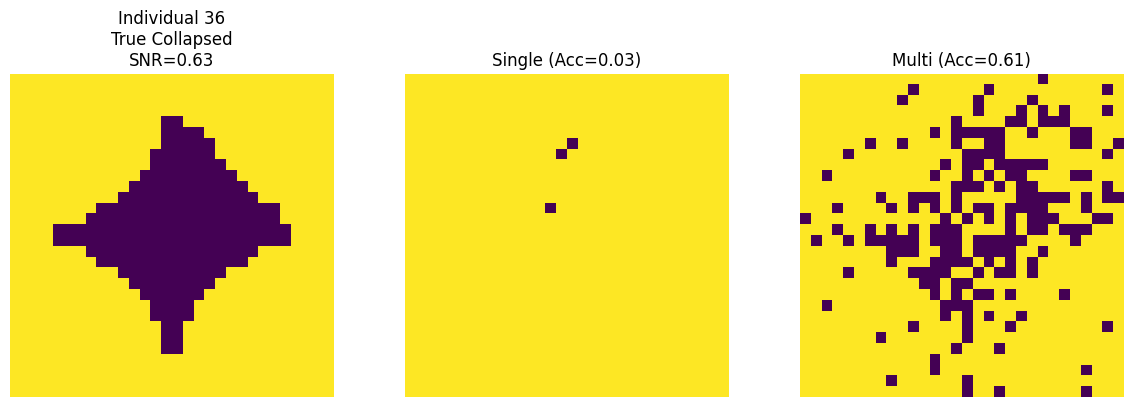

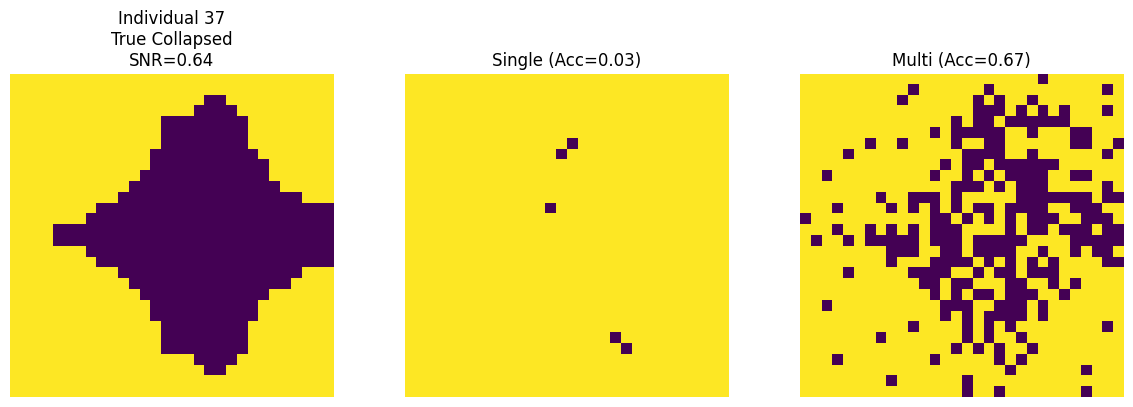

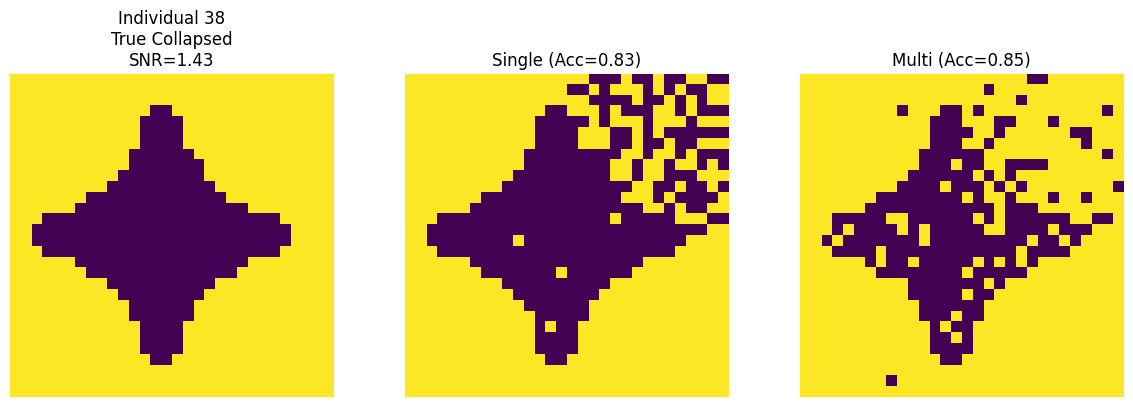

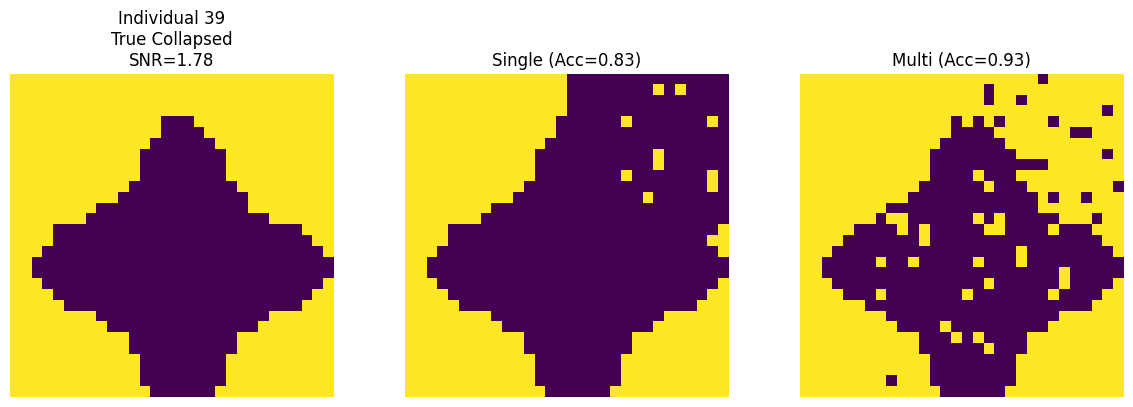

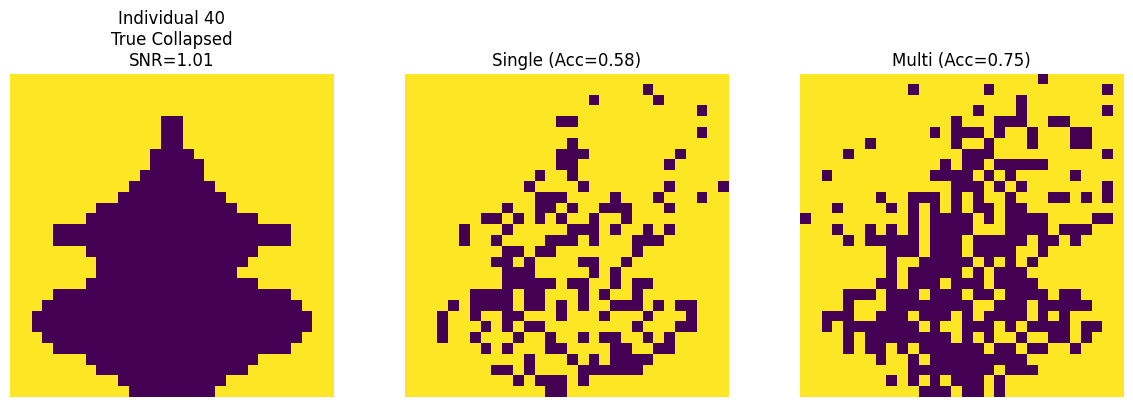

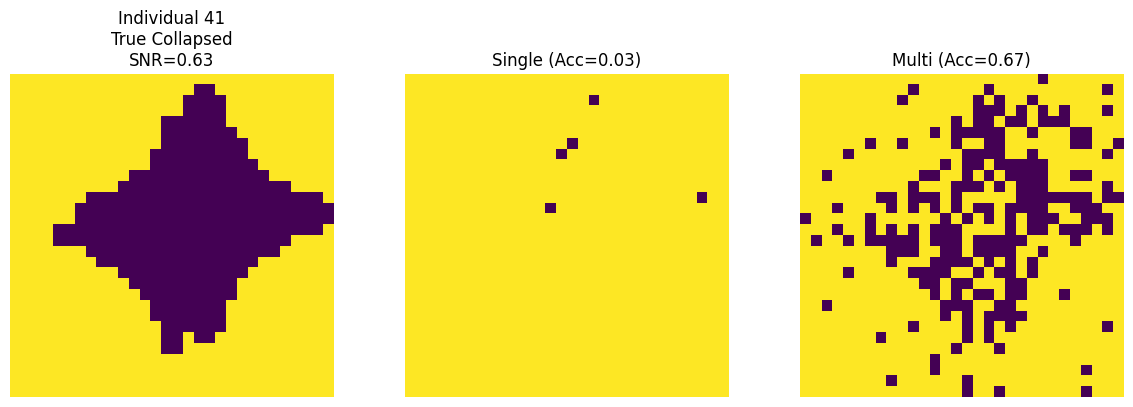

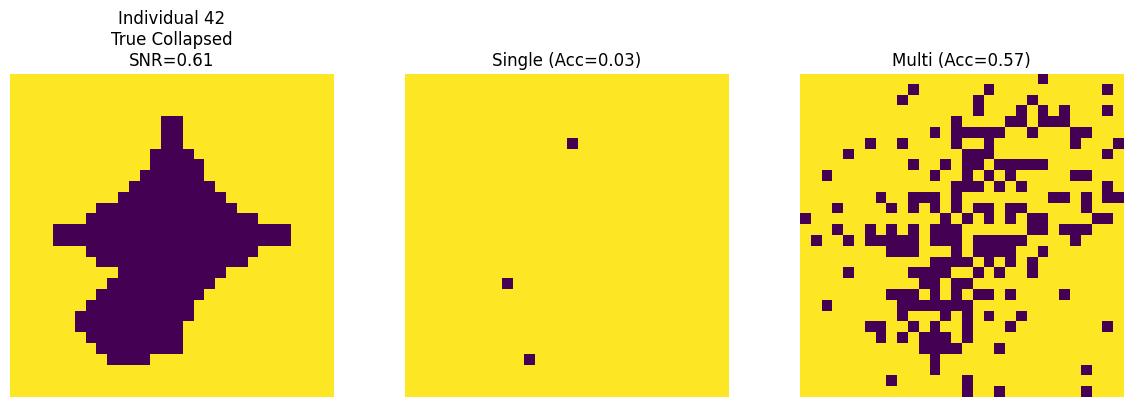

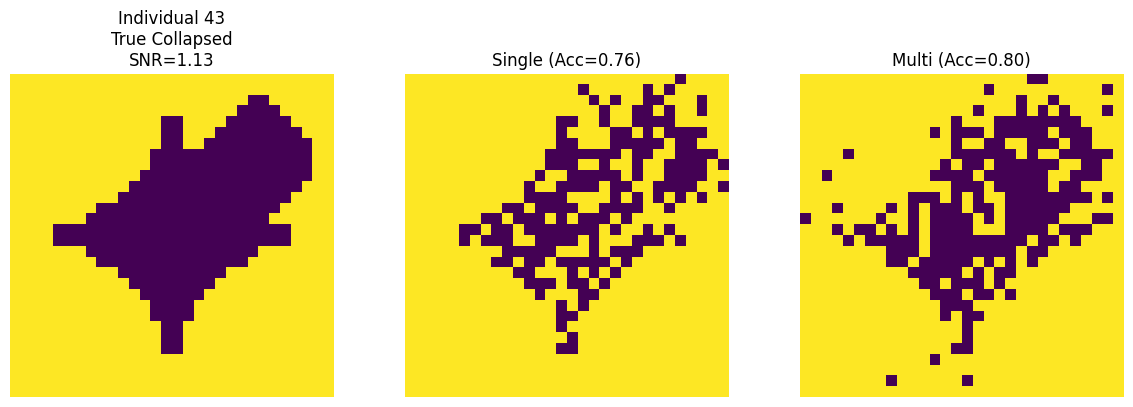

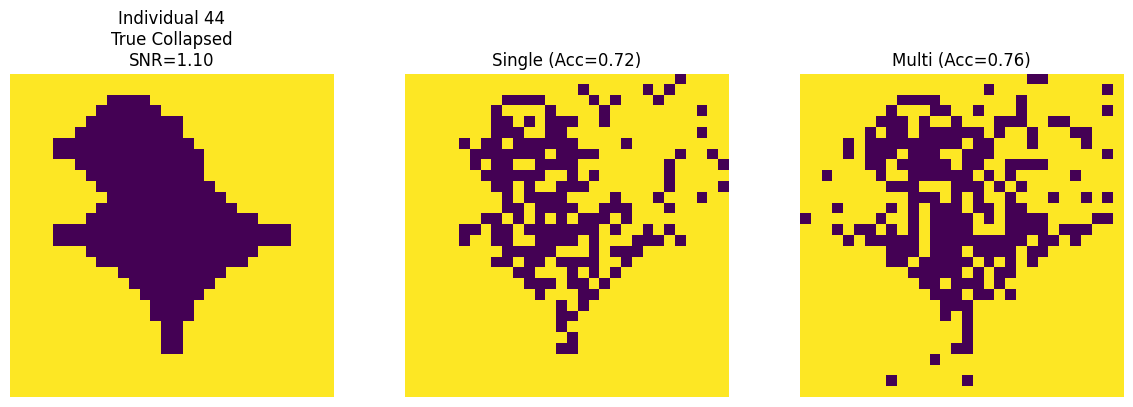

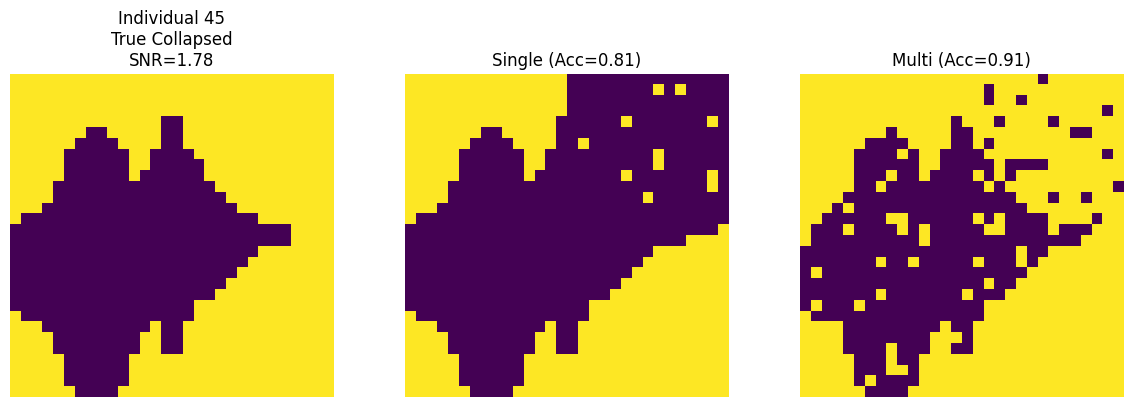

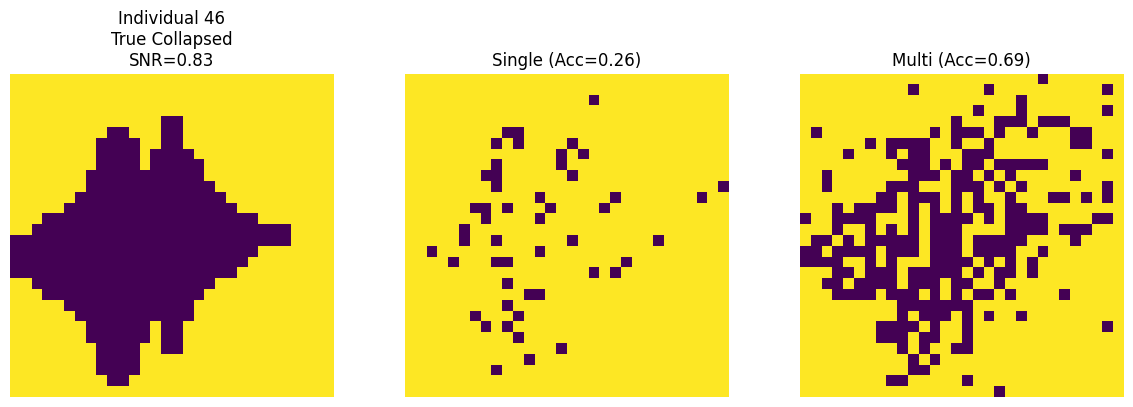

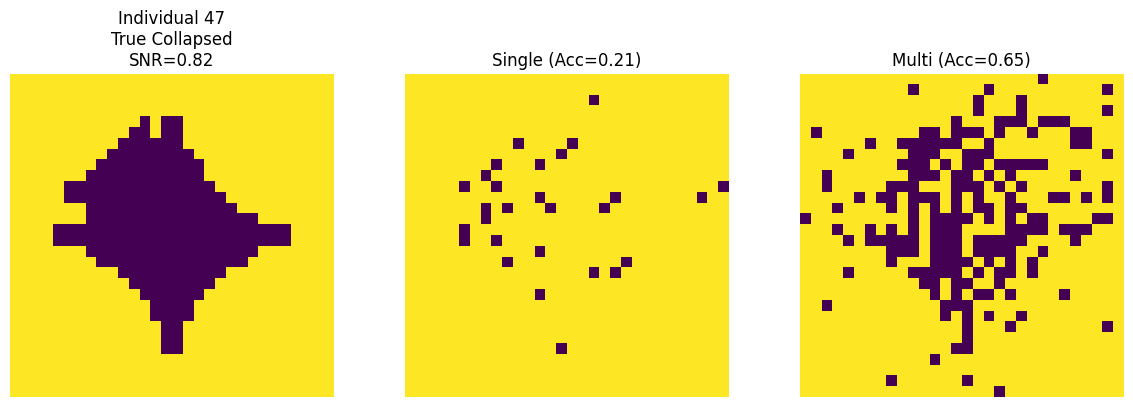

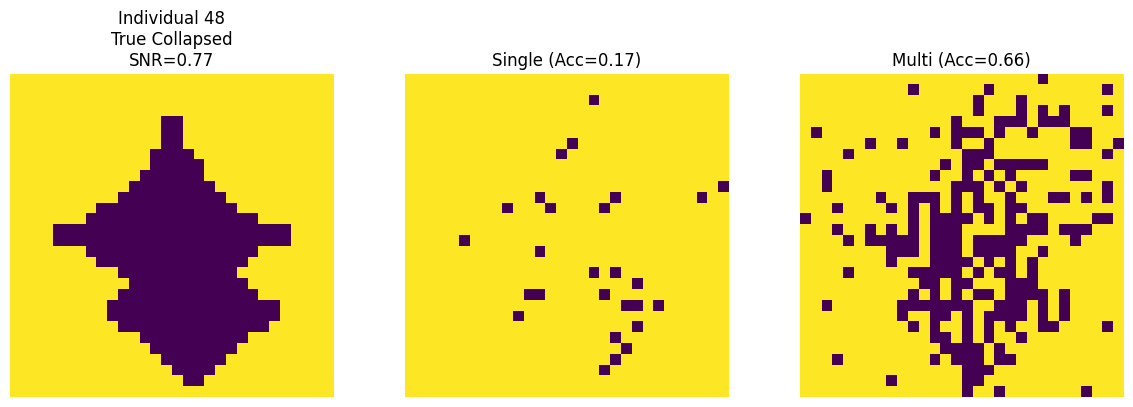

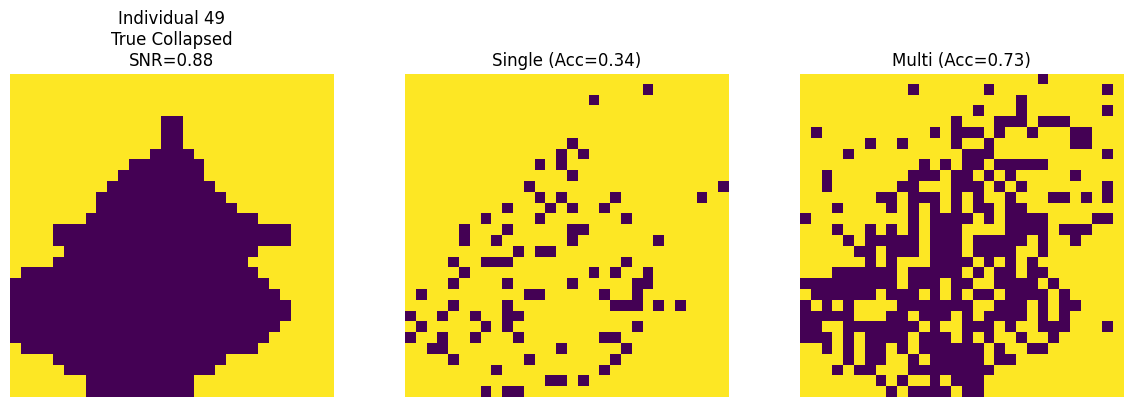

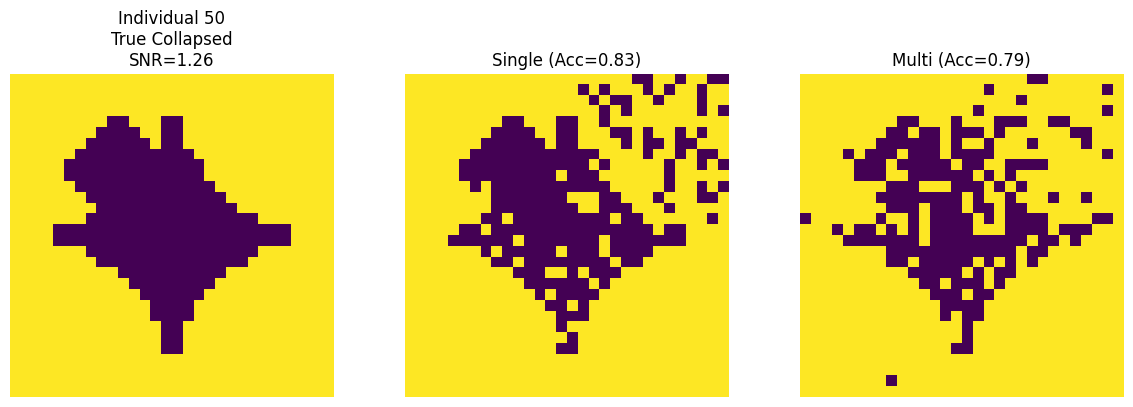

In [ ]:
n_individuals = len(U_collapsed_list)
for i in range(n_individuals):
    # Extract metrics for this individual
    snr_factor = results_df[results_df['individual'] == i]['snr_factor'].values
    snr_factor = snr_factor[0] if len(snr_factor) > 0 else np.nan

    acc_single = results_df[(results_df['individual'] == i) & (results_df['type'] == 'single_threshold')]['accuracy'].values
    acc_multi  = results_df[(results_df['individual'] == i) & (results_df['type'] == 'multi')]['accuracy'].values
    
    acc_single = acc_single[0] if len(acc_single) > 0 else np.nan
    acc_multi  = acc_multi[0] if len(acc_multi) > 0 else np.nan

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # --- True Collapsed ---
    true_label = np.argmax(U_collapsed_list[i].cpu().numpy(), axis=0).reshape(30, 30)
    axes[0].imshow(true_label.T, cmap='viridis')
    axes[0].set_title(f'Individual {i+1}\nTrue Collapsed\nSNR={snr_factor:.2f}')
    axes[0].axis('off')
    
    # --- Single Threshold Estimate ---
    single_label = np.argmax(parcellation_single[i], axis=0).reshape(30, 30)
    axes[1].imshow(single_label.T, cmap='viridis')
    axes[1].set_title(f'Single (Acc={acc_single:.2f})')
    axes[1].axis('off')
    
    # --- Multi Contrast Estimate ---
    multi_label = np.argmax(parcellation_multi[i], axis=0).reshape(30, 30)
    axes[2].imshow(multi_label.T, cmap='viridis')
    axes[2].set_title(f'Multi (Acc={acc_multi:.2f})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


